# Import Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [2]:
data = pd.read_csv('../input/datasets/kandij/mall-customers/Mall_Customers.csv')

In [3]:
data.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.shape

(200, 5)

In [5]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Genre,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
data.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [8]:
print(f'rows in data = {data.shape[0]}')
print(f'Duplicate rows in data = {data.duplicated().sum()}')

rows in data = 200
Duplicate rows in data = 0


In [9]:
data['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

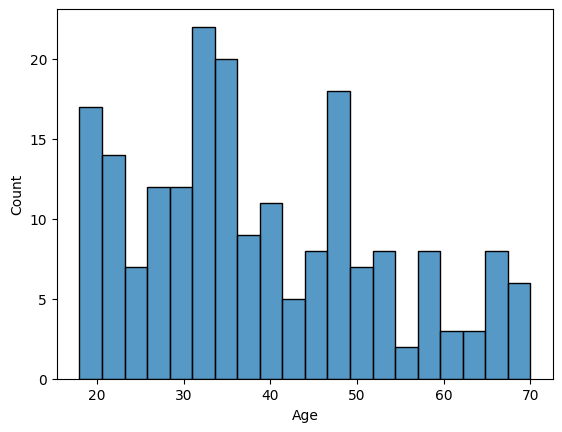

In [10]:
sns.histplot(data, x='Age', bins=20)
plt.show()

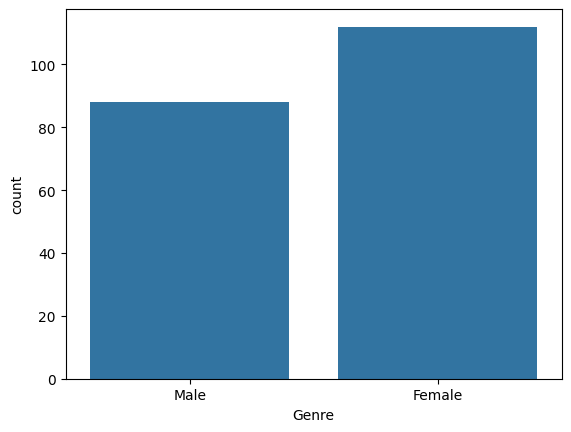

In [11]:
sns.countplot(data, x='Genre')
plt.show()

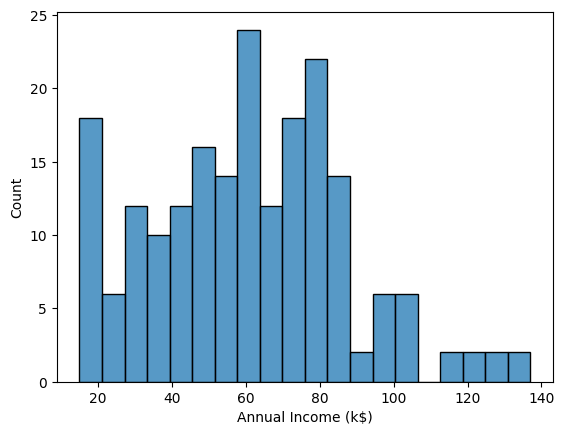

In [12]:
sns.histplot(data, x='Annual Income (k$)', bins=20)
plt.show()

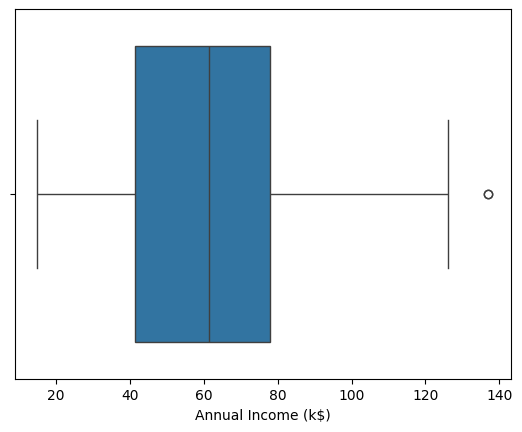

In [13]:
sns.boxplot(data, x='Annual Income (k$)')
plt.show()

In [14]:
data[data['Annual Income (k$)'] > 120].shape[0]

4

In [15]:
data = data[data['Annual Income (k$)'] <= 120]

In [16]:
data.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


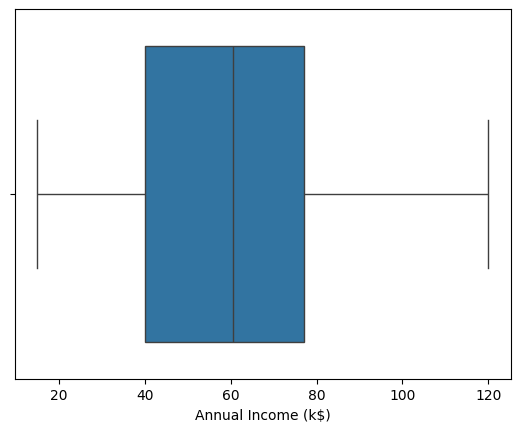

In [17]:
sns.boxplot(data, x='Annual Income (k$)')
plt.show()

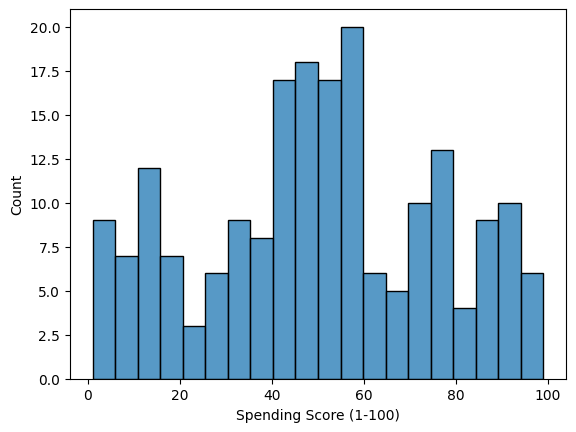

In [18]:
sns.histplot(data, x='Spending Score (1-100)', bins=20)
plt.show()

/tmp/ipykernel_17/1472760211.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, x="Spending Score (1-100)",shade=True, hue="Genre")


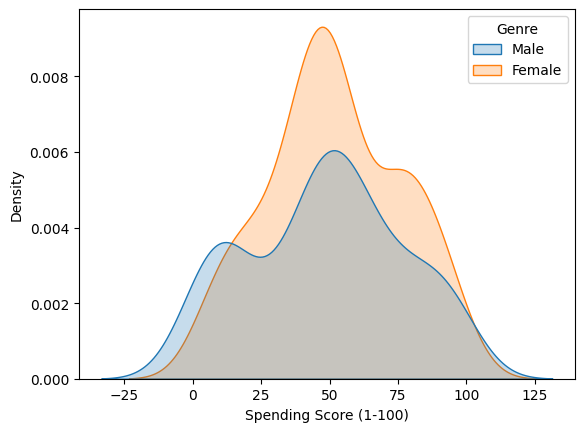

In [19]:
sns.kdeplot(data, x="Spending Score (1-100)",shade=True, hue="Genre")
plt.show()

/tmp/ipykernel_17/2376414971.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, x="Annual Income (k$)",shade=True, hue="Genre")


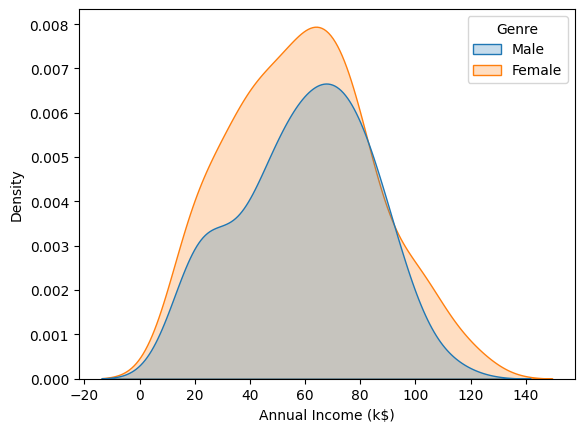

In [20]:
sns.kdeplot(data, x="Annual Income (k$)",shade=True, hue="Genre")
plt.show()

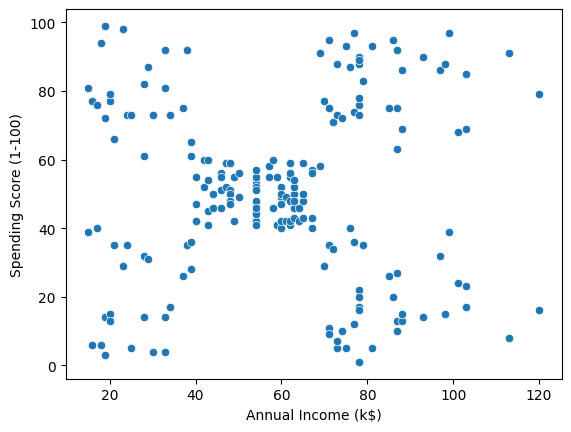

In [21]:
sns.scatterplot(data, x='Annual Income (k$)', y='Spending Score (1-100)')
plt.show()

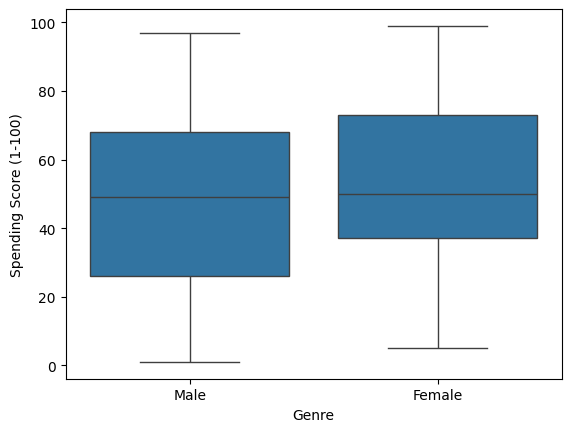

In [22]:
sns.boxplot(data, x="Genre",y="Spending Score (1-100)")
plt.show()

In [23]:
data = data.drop('CustomerID', axis=1)

In [24]:
data.head(5)

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


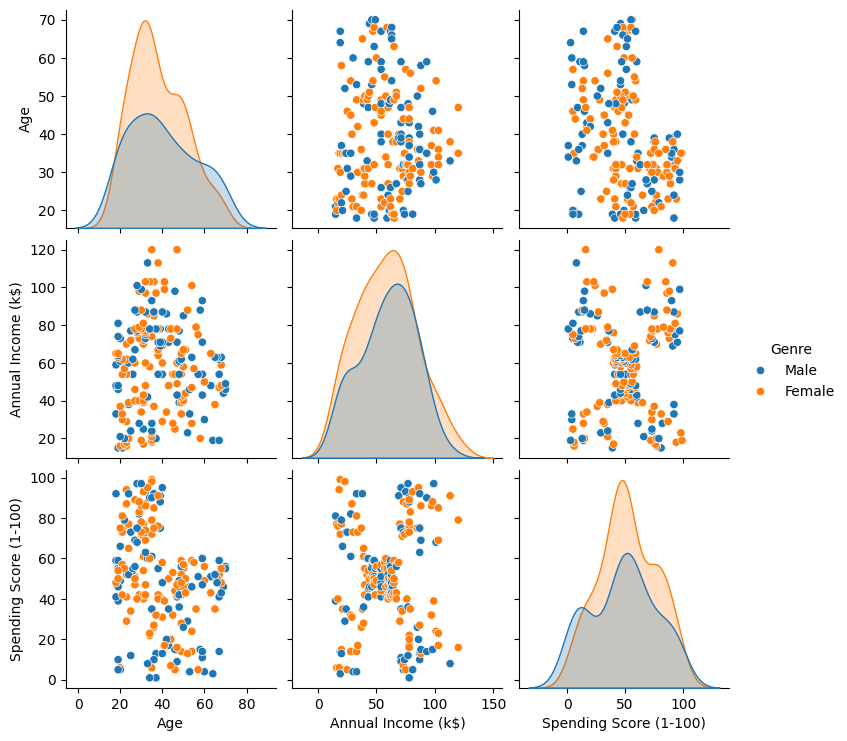

In [25]:
sns.pairplot(data,hue="Genre")

In [26]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
data['Genre'] = label.fit_transform(data['Genre'])

In [27]:
corr = data.corr()
corr

,Genre,Age,Annual Income (k$),Spending Score (1-100)
Genre,1.000000,0.073076,0.021719,-0.068899
Age,0.073076,1.000000,0.005431,-0.326891
Annual Income (k$),0.021719,0.005431,1.000000,0.009624
Spending Score (1-100),-0.068899,-0.326891,0.009624,1.000000


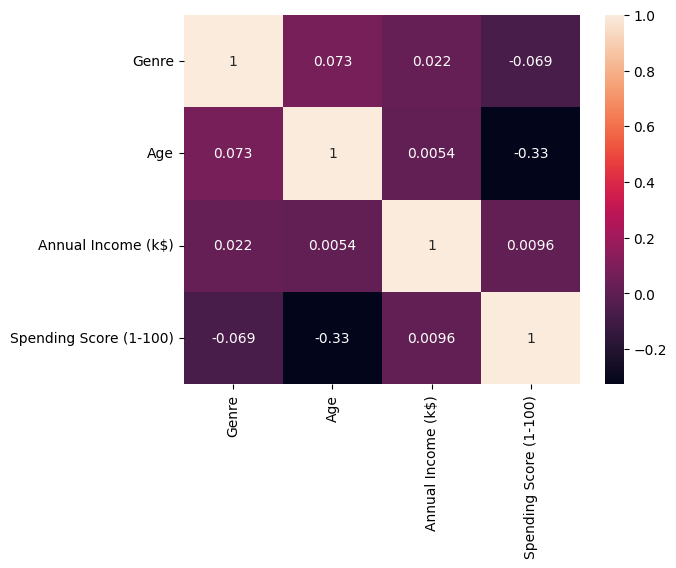

In [28]:
sns.heatmap(corr, annot=True)
plt.show()

# Data Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[['Age', 'Annual Income (k$)','Spending Score (1-100)']] = scaler.fit_transform(data[['Age', 'Annual Income (k$)','Spending Score (1-100)']])

# K-Means

In [30]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 14):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    inertia.append(kmeans.inertia_)

In [31]:
inertia

[636.1377551020407,
 430.0840132349973,
 343.69272617783656,
 248.33459607550364,
 208.8630506737386,
 171.57514990099446,
 160.16829105154414,
 146.46614925270248,
 135.31864677521673,
 125.81199399766744,
 111.83542864726306,
 104.2089026156097,
 100.61515432093418]

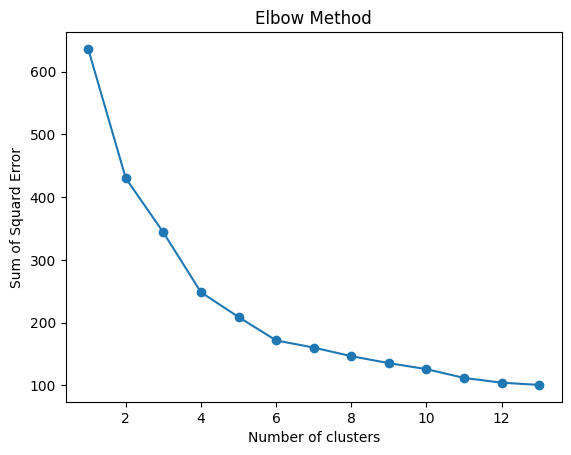

In [32]:
plt.plot(range(1, 14), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of Squard Error')
plt.show()

In [33]:
n_clusters = 5

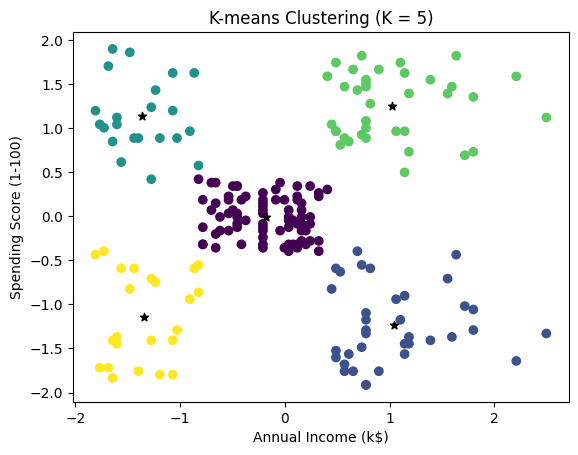

In [34]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data[['Annual Income (k$)', 'Spending Score (1-100)']])

plt.scatter(data['Annual Income (k$)'], data['Spending Score (1-100)'], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],color='black',marker='*')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-means Clustering (K = {n_clusters})')
plt.show()